# Barcelona Traffic Accidents: Geospatial & Administrative Safety Profiling
This notebook shifts our analytical focus from temporal trends to spatial dimensions. By evaluating traffic incident distributions across Barcelona's 10 Districts, 73 Neighborhoods (Barris), and key transit streets, we aim to uncover structural localized hot spots and safety anomalies.

### Core Metrics Tracked:
1. **Absolute Crash Footprint**: Total counts of incidents across locations.
2. **Severity Concentration (`target`)**: The mean rate of severe injuries or fatalities per location.
3. **Casualty Magnitude**: Average number of injured or deceased individuals per incident.

***NOTE: accidents and victims are highly correlated therefore I will limit the analysis to num_accidents and target***

## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import python_files.functions_barcelona as fb
import python_files.paths_mapping as pm
import python_files.functions_plotting as fp

import geopandas as gpd
import geopy
import geocoder
import osmnx
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter



# Set visual preferences
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [66]:
year = 2025
accidents = pd.read_csv(pm.FILES_PATH / f'accidents_weather{year}.csv',parse_dates=['datetime'])

if accidents.isnull().sum().sum() != 0:
    print(accidents.isnull().sum()[accidents.isnull().sum()>0].index)

accidents['target'] = ((accidents['num_deaths'] + accidents['num_severly_injured'])>0).astype(int)
int_columns =['hour', 'target','num_deaths','num_victims']
for col in int_columns:
    accidents[col] =accidents[col].astype(int)
accidents['weekday'] = accidents['weekday'].str[:3]
accidents['month'] = accidents['month'].str[:3]
accidents['street_name'] = accidents['street_name'].str.lower().str.strip()
print(accidents.district.value_counts())
##Dropping Desconegut in district and neighborhood
to_drop = accidents[accidents.district == 'Desconegut'].index
accidents.drop(to_drop,inplace=True)
accidents.shape

district
Eixample               40347
Sant Martí             17284
Sarrià-Sant Gervasi    15629
Sants-Montjuïc         15410
Horta-Guinardó         10349
Les Corts               9915
Sant Andreu             9153
Ciutat Vella            8025
Nou Barris              7788
Gràcia                  7200
Desconegut               238
Name: count, dtype: int64


(141100, 30)

In [ ]:
## Name Cleaning

In [94]:

accidents = accidents.replace('antonio lópez','idrissa diallo')

## 1. **District Analysis — Volume vs. Severity Rate**

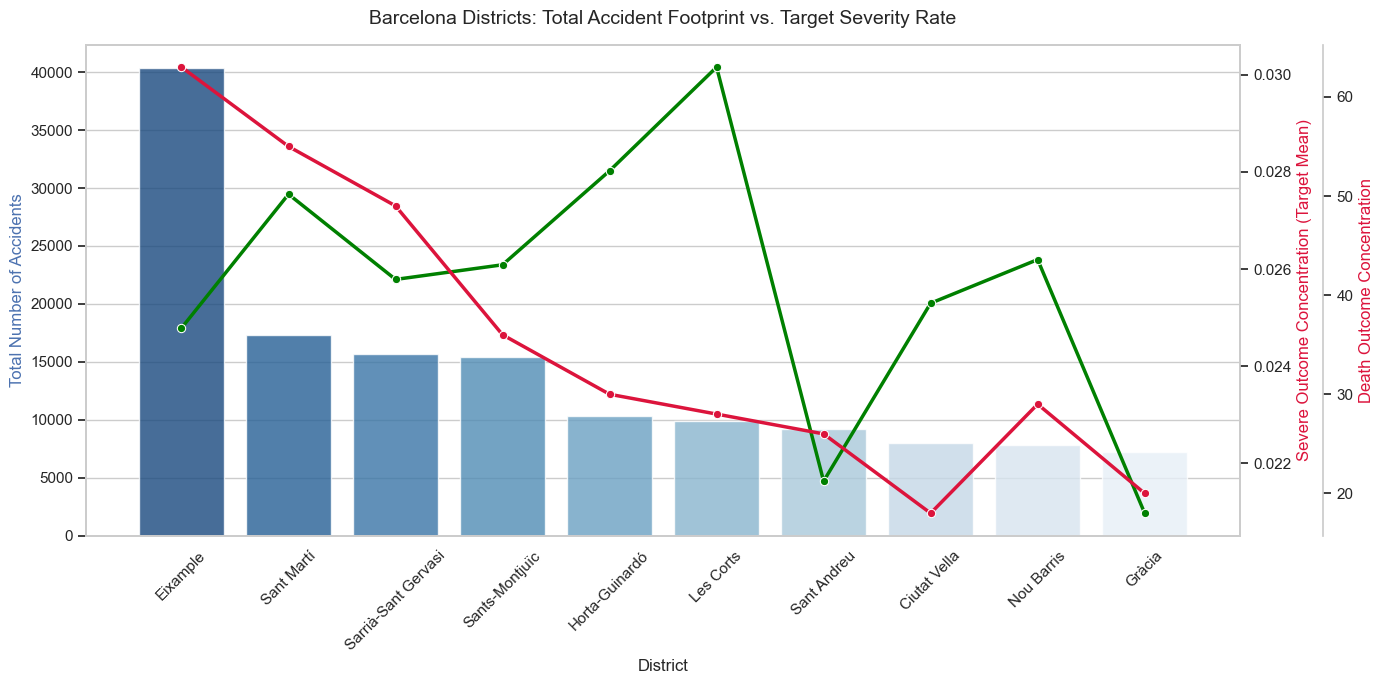

In [95]:
# Aggregate data by District
district_stats = accidents.groupby('district').agg(
    total_accidents=('num_incident', 'count'),
    total_deaths=('num_deaths','sum'),
    severity_rate=('target', 'mean'),
    
).sort_values(by='total_accidents', ascending=False).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 7))

# Primary Axis: Absolute Volume Bar Chart
sns.barplot(data=district_stats, x='district',
            y='total_accidents',
            ax=ax1,
            hue ='district',
            alpha=0.8, 
            errorbar=None, 
            palette ='Blues_r')
ax1.set_title('Barcelona Districts: Total Accident Footprint vs. Target Severity Rate', pad=15)
ax1.set_xlabel('District')
ax1.set_ylabel('Total Number of Accidents', color='b')
ax1.tick_params(axis='x', rotation=45)


# Secondary Axis: Severity Rate Line Chart
ax2 = ax1.twinx()
sns.lineplot(data=district_stats, x='district', y='severity_rate', ax=ax2, color='green', marker='o', linewidth=2.5, sort=False)
ax2.set_ylabel('Severe Outcome Concentration (Target Mean)', color='crimson')
ax2.grid(False)

ax3 = ax1.twinx()
sns.lineplot(data=district_stats, x='district', y='total_deaths', ax=ax3, color='crimson', marker='o', linewidth=2.5, sort=False)
ax3.set_ylabel('Death Outcome Concentration', color='crimson')
ax3.spines['right'].set_position(('outward', 60))
ax3.grid(False)

plt.tight_layout()
plt.show()

> Eixample is the district with most accidents, deaths (and victims) but is Les Corts the district with the highest target mean.


In [96]:
#Curious to know the top neighborhoods in these districts? Les Corts, Horta-Guinardo and Sant Marti
top_districts = district_stats.sort_values('severity_rate',ascending=False).iloc[0:3]['district'].tolist()
accidents[accidents.district.isin(top_districts)].groupby(['neighborhood','district'])[['target']].mean().sort_values('target',ascending=False).iloc[:5]

,,target
neighborhood,district,
Provençals del Poblenou,Sant Martí,0.042589
Can Baró,Horta-Guinardó,0.036765
el Baix Guinardó,Horta-Guinardó,0.035779
la Maternitat i Sant Ramon,Les Corts,0.031726
el Guinardó,Horta-Guinardó,0.031604


[Go back top](##Plotting:-TIME-BASED-FEATURES)


## 2. **Neighborhood Analysis — The Risk Quadrant Matrix**

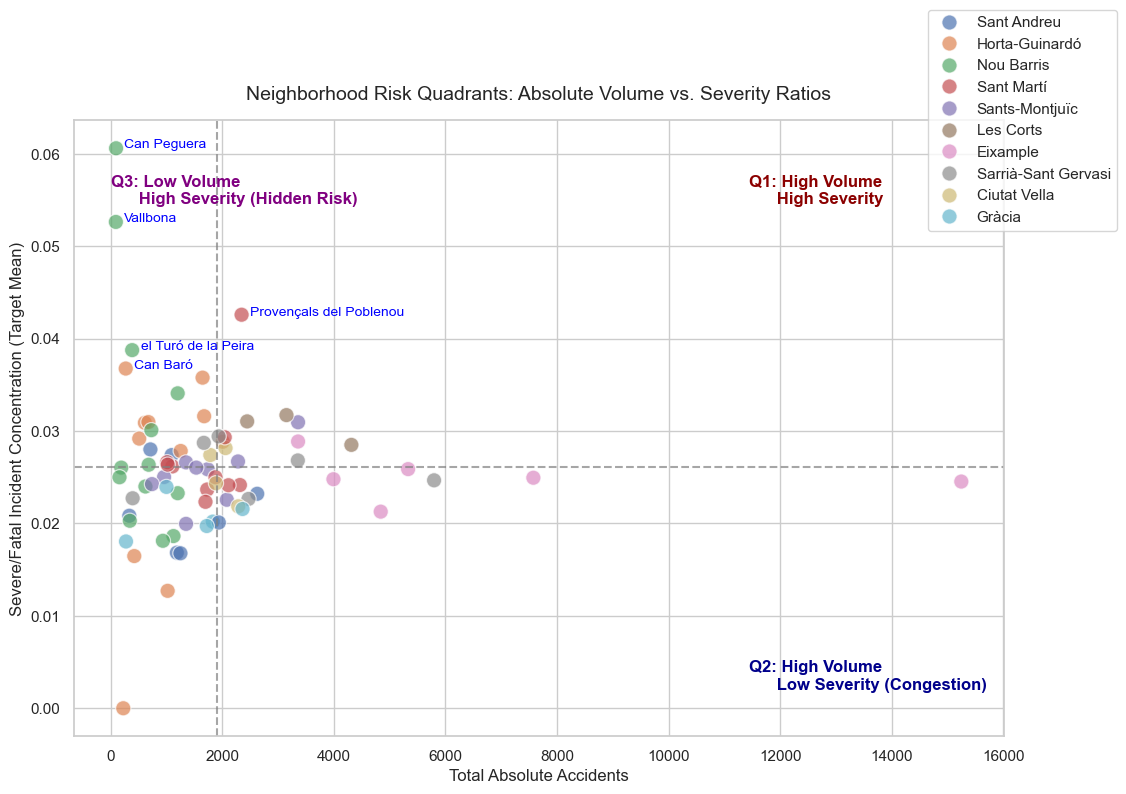

In [97]:
# Aggregate data by Neighborhood
neigh_stats = accidents.groupby(['neighborhood','district']).agg(
    total_accidents=('num_incident', 'count'),
    target_rate=('target', 'mean')
).reset_index()

avg_volume = neigh_stats['total_accidents'].mean()
avg_severity = neigh_stats['target_rate'].mean()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=neigh_stats, x='total_accidents', y='target_rate', hue='district',alpha=0.7, color='teal', s=120)
# sns.move_legend(ax, "center left", bbox_to_anchor=(1, 0.5), title="Species")

# Structural benchmark divider lines
plt.axvline(avg_volume, color='gray', linestyle='--', alpha=0.7)
plt.axhline(avg_severity, color='gray', linestyle='--', alpha=0.7)
#Top neigh label
top_neighs = neigh_stats.set_index('neighborhood').sort_values('target_rate',ascending=False).iloc[:5]
for idx, row in top_neighs.iterrows():
    plt.text(
        x=row["total_accidents"] + 150,  # Slight x-offset so text doesn't overlap dot
        y=row["target_rate"],  # y-coordinate
        s=idx,  # The text string to display
        fontdict=dict(color="blue", size=10),  # Style customization
    )

# Quadrant Labels
plt.text(neigh_stats['total_accidents'].max()*0.75, neigh_stats['target_rate'].max()*0.9, 'Q1: High Volume\n      High Severity', color='darkred', weight='bold')
plt.text(neigh_stats['total_accidents'].max()*0.75, 0.002, 'Q2: High Volume\n      Low Severity (Congestion)', color='darkblue', weight='bold')
plt.text(1, neigh_stats['target_rate'].max()*0.9, 'Q3: Low Volume\n      High Severity (Hidden Risk)', color='purple', weight='bold')
plt.legend(loc='center', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
plt.title('Neighborhood Risk Quadrants: Absolute Volume vs. Severity Ratios', pad=15)
plt.xlabel('Total Absolute Accidents')
plt.ylabel('Severe/Fatal Incident Concentration (Target Mean)')
plt.show()

> Going over the neighborhoods, classify the neighborhoods based in the average number of accidents an average of severity.
> 1. Q1. High Volume-High Severity. Average volume over 75% of the average volume and 90% of severity average
> 2. Q2. High Volume-Low Severity.  Average volume over 75%
> 3. Q3. Low Volume-High Severyty. Average Severity over 90%.
> 4. Q4. Low Volume-Low Severity. The rest.

In [98]:


def applying_quadrants(row, volume_threshold_percentile = 0.6, severity_threshold_percentile =0.75):
    volume_threshold = neigh_stats['total_accidents'].quantile(volume_threshold_percentile)
    severity_threshold = neigh_stats['target_rate'].quantile(severity_threshold_percentile)
    
    if (row['total_accidents'] >  volume_threshold) and (row['target_rate'] > severity_threshold):
        return 'Q1'
    elif (row['total_accidents'] >  volume_threshold) and (row['target_rate'] < severity_threshold):
        return 'Q2'
    elif row['target_rate'] > severity_threshold:
        return 'Q3'
    else:
        return 'Q4'

neigh_stats['neigh_quartiles'] = neigh_stats.apply(applying_quadrants,axis=1)
neigh_stats[neigh_stats.neigh_quartiles =='Q1'].sort_values(['target_rate','district'],ascending=False)[['neighborhood','district','target_rate']].head()

,neighborhood,district,target_rate
12,Provençals del Poblenou,Sant Martí,0.042589
58,la Maternitat i Sant Ramon,Les Corts,0.031726
10,Pedralbes,Les Corts,0.031046
57,la Marina del Prat Vermell,Sants-Montjuïc,0.030952
73,les Tres Torres,Sarrià-Sant Gervasi,0.029427


## 3. **Street-Level Analysis — Top Contributors Filtering**

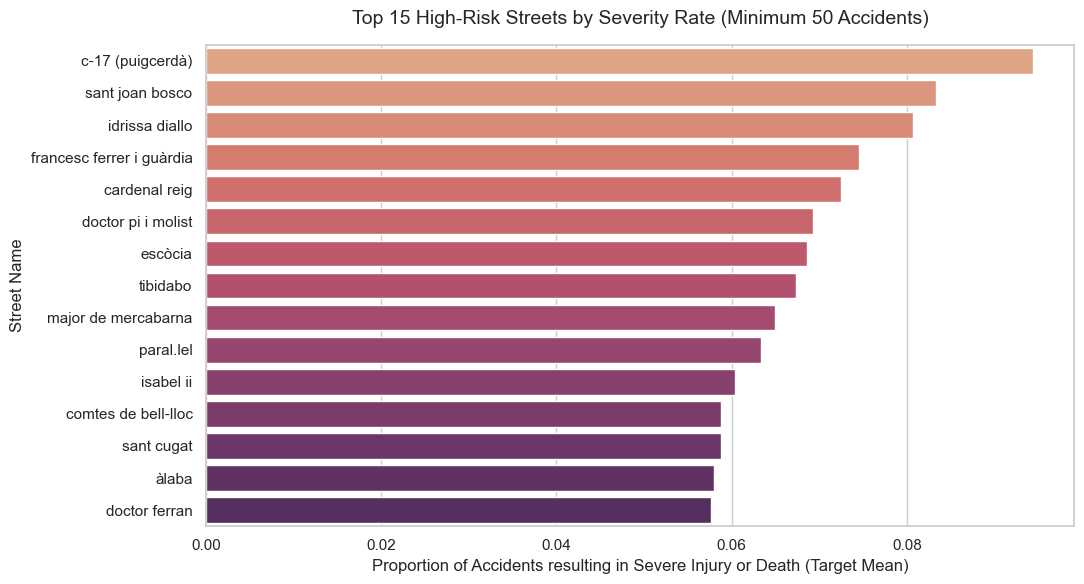

In [99]:
# Grouping by street and filtering for statistical relevance
street_stats = accidents.groupby('street_name').agg(
    total_accidents=('num_incident', 'count'),
    target_mean=('target', 'mean')
).reset_index()

# Filter: Street must have at least 50 accidents to evaluate severity fairly
volume_threshold = 50 
significant_streets = street_stats[street_stats['total_accidents'] >= volume_threshold]

# Extract Top 15 streets by severe crash concentration
top_dangerous_streets = significant_streets.sort_values(by='target_mean', ascending=False).head(15)

plt.figure(figsize=(11, 6))
sns.barplot(data=top_dangerous_streets, x='target_mean', y='street_name', hue='street_name', legend=False, palette='flare')
plt.title(f'Top 15 High-Risk Streets by Severity Rate (Minimum {volume_threshold} Accidents)', pad=15)
plt.xlabel('Proportion of Accidents resulting in Severe Injury or Death (Target Mean)')
plt.ylabel('Street Name')
plt.tight_layout()
plt.show()

> Streets with the higher severity index are not the main streets. These streets are roads like c-17 (and it suggests high speed crushes) and/or secondary roads (what means after works late nioght incidents).

In [180]:
accidents[accidents.street_name.str.contains('meridiana')]['street_name'].unique()

for name in accidents.head(30).iterrows():
    print(name)


(0, num_incident                          2010S003688
district_code                                10.0
district                               Sant Martí
neighborhood           el Camp de l'Arpa del Clot
street_name                             meridiana
weekday                                       Fri
year                                       2010.0
month                                         May
day                                          28.0
hour                                           19
ped_cause                           No peds fault
num_deaths                                      0
num_minorly_injured                           0.0
num_severly_injured                           0.0
num_victims                                     0
num_vehicles                                  1.0
lon                                       2.18657
lat                                     41.413149
datetime                      2010-05-28 19:00:00
temp_avg                                     1

In [164]:
accidents[accidents.street_name.str.contains('cardenal reig')]['street_name'].unique()
barcelona_streets.fillna(0,inplace=True)
#barcelona_streets[barcelona_streets.name.str.contains('Mercabarna')]
'Carrer Major de Mercabarna' in barcelona_streets.name.explode().value_counts()

False

In [152]:
key_word = 'Carrer Major de Mercabarna'
for name in top_10_names:
    print(name.upper(), name.lower() in barcelona_streets.name)
for name in barcelona_streets.name:
    if isinstance(name,list):
        new_name = ' / '.join(name)
        if key_word in new_name.lower():
            print(name)
    elif isinstance(name,str):
        if key_word in name.lower():
            print(name)


C-17 (PUIGCERDÀ) False
PASSEIG DE SANT JOAN BOSCO False
IDRISSA DIALLO False
AVINGUDA DE FRANCESC FERRER I GUÀRDIA False
CARRER DEL CARDENAL REIG False
CARRER DEL DOCTOR PI I MOLIST False
CARRER D'ESCÒCIA False
AVINGUDA DEL TIBIDABO False
MAJOR DE MERCABARNA False
AVINGUDA DEL PARAL·LEL False


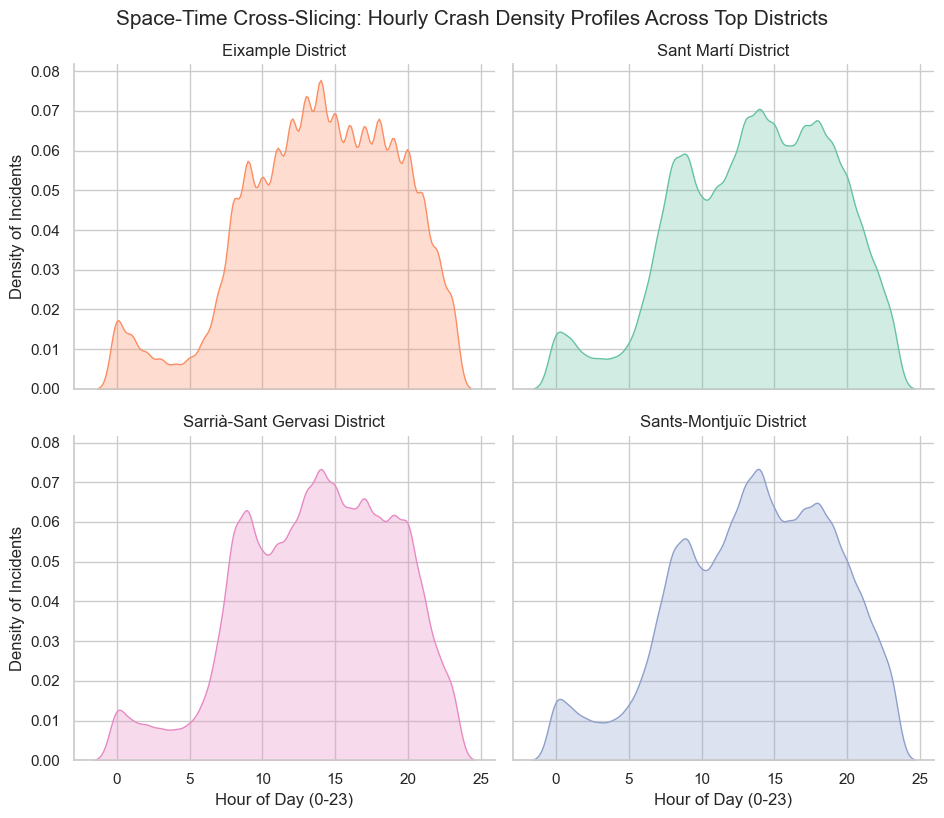

In [16]:
# Filter for top 4 districts by volume to keep small-multiples clear
top_4_districts = district_stats['district'].head(4).tolist()
cross_slice_df = accidents[accidents['district'].isin(top_4_districts)]

# Create the Faceted Hourly Profile Line Plot
g = sns.FacetGrid(cross_slice_df, col="district", col_order=top_4_districts, 
                  hue="district", palette="Set2", height=4, aspect=1.2, col_wrap=2)
g.map(sns.kdeplot, "hour", bw_adjust=0.7, fill=True, alpha=0.3)

g.set_titles(col_template="{col_name} District")
g.set_axis_labels("Hour of Day (0-23)", "Density of Incidents")
g.fig.suptitle('Space-Time Cross-Slicing: Hourly Crash Density Profiles Across Top Districts', y=1.02, size=15)

plt.show()

> Accidents, victims, deaths and target grow during the week to peak on Friday. After that, they have a steep decrease during the weekend.

> Ratios are different: they peak on Saturday (all of them; collecting data from Saturday morning--Friday night) and while deaths and accidents diminish going into Sunday, the raio for the target stay stable.

## 4. **Hourly Profiles**

In [ ]:
list_hours =list(range(0,24))
fp.viz_per_time_period(accidents,'hour',list_hours)

> As usual, accidents and victims move together while deaths and target have a different peak at a later hour.

> Ratios are different: they peak around 5 AM, all of them. From then on, although the number of victims keeps stable and even increasing, the other two ratios stabilize at a lower level.

## 5.1 **Weekend Analysis**.

# Summary:
### *Accidents, Deaths, victims and target*.
1. Yearly Trajectory (Long-Term Macro Trends)

> Observation: The data reveals a general historical reduction in total accidents, injuries, and deaths over the 15-year span.

> Anomalies: A sharp, significant dip occurs in 2020 (corresponding with global pandemic mobility restrictions). While volumes have steadily recovered in the years since, they remain substantially lower than pre-2020 baselines

2. Monthly Seasonality & The Risk Paradox.
   
> Observation: The months of April and August stand out as the primary high-severity intervals.

> Insight: While August experiences a massive drop in absolute traffic volumes due to summer holidays , it records some of the highest per-accident mortality ratios and target variable rates. This indicates that although accidents are less frequent in August, they are statistically more severe when they do occur (often due to higher transit speeds on emptier city streets and dui).

3. Weekly Patterns (Weekday Volume vs. Weekend Risk)

> Observation: Friday is the peak day for absolute accident volumes, acting as the transition bridge between professional commuting and leisure travel.

> Insight: Conversely, Saturday dominates in terms of per-accident impact ratios and the target severity rate. This represents a distinct behavioral cohort shift: weekdays drive high-volume but minor bumper-to-bumper congestion accidents, whereas weekends see fewer but much more dangerous collisions.

4. Hourly Profiles (Daily Activity vs. Midnight Vulnerability)

> Observation: High-volume traffic hours (the morning and evening rush-hour windows) host the highest absolute number of incidents.

> Insight: However, the severe impact ratios and the target rate inversely peak during late-night and early-morning windows (specifically between 02:00 AM and 05:00 AM). Despite low traffic density, reduced visibility, driver fatigue, and potential impairment cause an escalation in severe injuries and fatalities per incident during these hours.

5. Weekend Analysis Validation

> Observation: Isolate-testing the weekend data perfectly consolidates and validates the localized trends noted above.

> Insight: The weekend cohort study confirms that a drop in vehicle exposure risk (lower absolute volume) directly correlates with an inflation of extreme safety failures (higher target mean and average deaths per accident). This emphasizes that human behavior and road conditions outside of working hours carry a fundamentally different and more critical safety profile.